#  ERK vs. AKT Propagation Comparison

In [3]:
from pathlib import Path
import sys
import subprocess
import json

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
PROJECT_ROOT = Path("..").resolve()

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
DATA_PATH = PROJECT_ROOT / "data" / "single-cell-tracks_exp1-6_noErbB2.csv.gz"
META_PATH = PROJECT_ROOT / "data" / "01-readme-experiment-description_2022-04-05.csv"

OUTPUT_ROOT = PROJECT_ROOT / "analysis_outputs"
FINAL_OUTPUT_DIR = PROJECT_ROOT / "outputs"

OUTPUT_ROOT.mkdir(exist_ok=True)
FINAL_OUTPUT_DIR.mkdir(exist_ok=True)

print("DATA exists:", DATA_PATH.exists())
print("META exists:", META_PATH.exists())
print("SCRIPT exists:", (SCRIPTS_DIR / "spatiotemporal_signal_propagation.py").exists())

DATA exists: True
META exists: True
SCRIPT exists: True


In [ ]:
# Select same experiment-site blocks for both biosensors

meta = pd.read_csv(META_PATH, encoding="utf-8-sig")
meta = meta.rename(columns={"Site": "Image_Metadata_Site"})

display(meta[["Image_Metadata_Site", "Mutation"]].drop_duplicates().head(10))

# Representative blocks: WT + two PI3K/AKT pathway mutants
selected_mutations = ["WT", "AKT1_E17K", "PTEN_del"]

selected_blocks = []

for mut in selected_mutations:
    sub = meta[meta["Mutation"] == mut].copy()
    
    if sub.empty:
        raise ValueError(f"No rows found for mutation: {mut}")
    
    row = sub.iloc[0]
    
    selected_blocks.append({
        "mutation": mut,
        "exp_id": int(row["Exp_ID"]) if "Exp_ID" in row else 1,
        "site_id": int(row["Image_Metadata_Site"])
    })

selected_blocks = pd.DataFrame(selected_blocks)
display(selected_blocks)

,Image_Metadata_Site,Mutation
0,1,WT
1,2,WT
2,3,WT
3,4,WT
4,5,AKT1_E17K
5,6,AKT1_E17K
6,7,AKT1_E17K
7,8,AKT1_E17K
8,9,PIK3CA_E545K
9,10,PIK3CA_E545K


,mutation,exp_id,site_id
0,WT,1,1
1,AKT1_E17K,1,5
2,PTEN_del,1,17


In [14]:
# Run spatiotemporal propagation for ERK and AKT/FoxO

signals = {
    "ERKKTR_ratio": "ERKKTR_ratio",
    "FoxO3A_ratio": "FoxO3A_ratio"
}

SPATIAL_RADIUS = 60
FUTURE_WINDOW = 3
JUMP_QUANTILE = 0.9

rows = []

for block in selected_blocks.itertuples(index=False):
    for signal_label, signal_col in signals.items():
        
        outdir = OUTPUT_ROOT / f"TaskB_{block.mutation}_{signal_label}"
        
        cmd = [
            sys.executable,
            str(SCRIPTS_DIR / "spatiotemporal_signal_propagation.py"),
            "--data-path", str(DATA_PATH),
            "--meta-path", str(META_PATH),
            "--exp-id", str(block.exp_id),
            "--site-id", str(block.site_id),
            "--signal-col", signal_col,
            "--spatial-radius", str(SPATIAL_RADIUS),
            "--future-window-frames", str(FUTURE_WINDOW),
            "--jump-quantile", str(JUMP_QUANTILE),
            "--output-dir", str(outdir),
        ]
        
        print(f"Running {block.mutation} | {signal_label}")
        result = subprocess.run(cmd, capture_output=True, text=True)
        
        if result.returncode != 0:
            print(result.stderr)
            raise RuntimeError(f"Script failed for {block.mutation} | {signal_label}")
        
        summary_path = (
            outdir /
            f"exp_{block.exp_id}_site_{block.site_id}_{signal_col}" /
            "summary.json"
        )
        
        with open(summary_path) as f:
            s = json.load(f)
        
        rows.append({
            "mutation": block.mutation,
            "exp_id": block.exp_id,
            "site_id": block.site_id,
            "biosensor": signal_label,
            "signal_col": signal_col,
            "jump_threshold_theta": s["jump_threshold"],
            "p_exposed": s["future_jump_rate_if_neighbor_jumps_now"],
            "p_unexposed": s["future_jump_rate_if_no_neighbor_jumps_now"],
            "risk_difference": s["risk_difference"],
            "RR": s["relative_risk"],
            "n_nodes": s["n_nodes"],
            "n_spatial_edges": s["n_spatial_edges"],
        })

b1_df = pd.DataFrame(rows)
display(b1_df)

Running WT | ERKKTR_ratio
Running WT | FoxO3A_ratio
Running AKT1_E17K | ERKKTR_ratio
Running AKT1_E17K | FoxO3A_ratio
Running PTEN_del | ERKKTR_ratio
Running PTEN_del | FoxO3A_ratio


,mutation,exp_id,site_id,biosensor,signal_col,jump_threshold_theta,p_exposed,p_unexposed,risk_difference,RR,n_nodes,n_spatial_edges
0,WT,1,1,ERKKTR_ratio,ERKKTR_ratio,0.036543,0.131455,0.074867,0.056588,1.755850,356632,2389504
1,WT,1,1,FoxO3A_ratio,FoxO3A_ratio,0.034870,0.153976,0.115367,0.038609,1.334666,356632,2389504
2,AKT1_E17K,1,5,ERKKTR_ratio,ERKKTR_ratio,0.022628,0.155272,0.096390,0.058883,1.610885,448311,3863383
3,AKT1_E17K,1,5,FoxO3A_ratio,FoxO3A_ratio,0.046550,0.152510,0.118690,0.033820,1.284947,448311,3863383
4,PTEN_del,1,17,ERKKTR_ratio,ERKKTR_ratio,0.074089,0.127403,0.080988,0.046416,1.573125,211139,830047
5,PTEN_del,1,17,FoxO3A_ratio,FoxO3A_ratio,0.046170,0.142073,0.105394,0.036679,1.348018,211139,830047


In [15]:
# Save comparison table

b1_df.to_csv(
    FINAL_OUTPUT_DIR / "B1_ERK_vs_AKT_comparison_table.csv",
    index=False
)

print("Saved:")
print(FINAL_OUTPUT_DIR / "B1_ERK_vs_AKT_comparison_table.csv")

Saved:
/home/m/biologiaSystemów/projekt2/outputs/B1_ERK_vs_AKT_comparison_table.csv


biosensor,ERKKTR_ratio,FoxO3A_ratio
mutation,,
AKT1_E17K,1.610885,1.284947
PTEN_del,1.573125,1.348018
WT,1.755850,1.334666


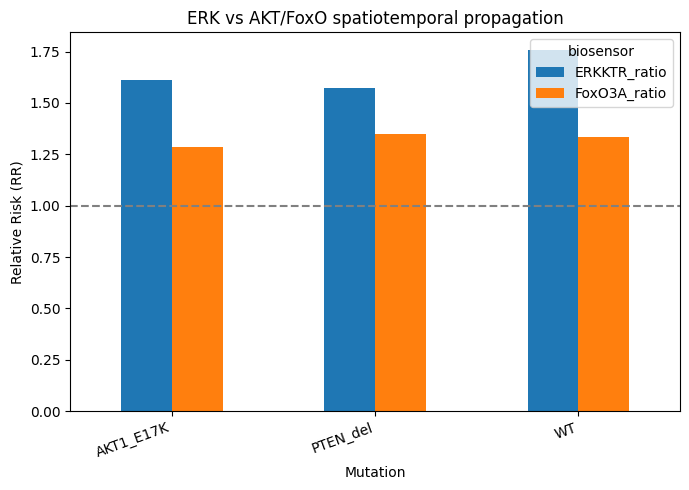

In [16]:
# Simple comparative plot: RR values

plot_df = b1_df.pivot(
    index="mutation",
    columns="biosensor",
    values="RR"
)

display(plot_df)

fig, ax = plt.subplots(figsize=(7, 5))

plot_df.plot(
    kind="bar",
    ax=ax
)

ax.axhline(1, linestyle="--", color="gray")

ax.set_ylabel("Relative Risk (RR)")
ax.set_xlabel("Mutation")
ax.set_title("ERK vs AKT/FoxO spatiotemporal propagation")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(
    FINAL_OUTPUT_DIR / "B1_ERK_vs_AKT_RR_barplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

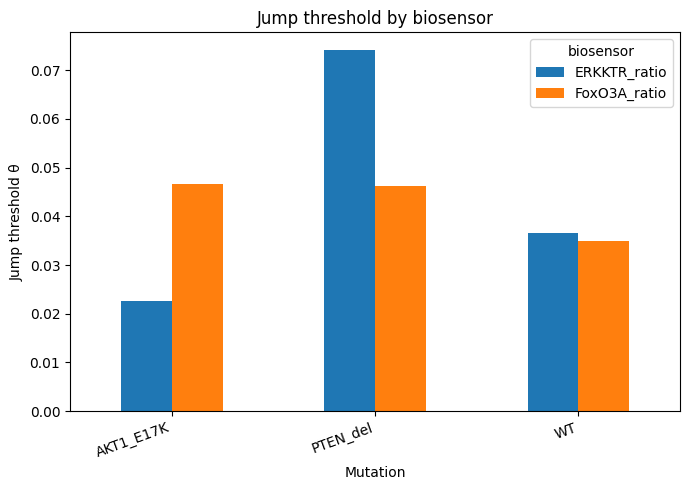

In [17]:
# drugi  plot: jump thresholds θ - dodatek

theta_df = b1_df.pivot(
    index="mutation",
    columns="biosensor",
    values="jump_threshold_theta"
)

fig, ax = plt.subplots(figsize=(7, 5))

theta_df.plot(
    kind="bar",
    ax=ax
)

ax.set_ylabel("Jump threshold θ")
ax.set_xlabel("Mutation")
ax.set_title("Jump threshold by biosensor")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(
    FINAL_OUTPUT_DIR / "B1_ERK_vs_AKT_theta_barplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
# Interpretation helper

erk_mean = b1_df[b1_df["biosensor"] == "ERKKTR_ratio"]["RR"].mean()
akt_mean = b1_df[b1_df["biosensor"] == "FoxO3A_ratio"]["RR"].mean()

print(f"Mean RR for ERK:      {erk_mean:.3f}")
print(f"Mean RR for AKT/FoxO: {akt_mean:.3f}")

if erk_mean > akt_mean:
    print("ERK shows stronger average spatiotemporal propagation than AKT/FoxO.")
elif akt_mean > erk_mean:
    print("AKT/FoxO shows stronger average spatiotemporal propagation than ERK.")
else:
    print("Both biosensors show similar average propagation strength.")

Mean RR for ERK:      1.647
Mean RR for AKT/FoxO: 1.323
ERK shows stronger average spatiotemporal propagation than AKT/FoxO.
